In [1]:
import torch
import pandas as pd
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import common.utils as cutils    
import common.bounding_boxes as bboxes
import os
from common.dataset import BiopsiesCSVDataset, TestBiopsiesCSVDataset
from tqdm import tqdm

In [2]:
import timm
model = timm.create_model(
    'vit_huge_plus_patch16_dinov3_qkvb.lvd1689m',#'vit_huge_plus_patch16_dinov3_qkvb.lvd1689m',
    pretrained=True,
    features_only = True,
    num_classes=0,  # remove classifier nn.Linear
)
model = model.eval()
model = model.cuda()

def embedding(img, model=model):
    # get model specific transforms (normalization, resize)
    data_config = timm.data.resolve_model_data_config(model)
    transforms = timm.data.create_transform(**data_config, is_training=False)

    transformed = transforms(img)#.unsqueeze(0) if len(img.shape) < 4 else transforms(img)
    transformed = transformed.cuda()
    # output = model(transformed)  # output is (batch_size, num_features) shaped tensor

    # or equivalently (without needing to set num_classes=0)

    # 
    # print(output.shape)
    output = model(transformed)
    output = output[-1]
    return output
    # output is unpooled, a (1, 261, 768) shaped tensor

    output = model.forward_features(transforms(img))
    output = model.forward_head(output, pre_logits=True)
    return output

In [3]:
df = pd.read_csv('../data/fresh/test.csv')
# df['biopsy'].unique()
# df = df[df['biopsy']=='49_101-55.5_S3']
df.groupby('target').count()

,image,biopsy,type,bbs,rects,mask_infiltrates,mask_background
target,,,,,,,
0,10907,10907,10907,10907,10907,0,0
1,10,10,10,10,10,0,0
2,291,291,291,291,291,4,3
3,1142,1142,1142,1142,1142,4,3


In [11]:
df2 = df[df['target']==2][df['mask_infiltrates'].notnull()].reset_index(drop=True)
df2

/tmp/ipykernel_1582187/272422582.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df[df['target']==2][df['mask_infiltrates'].notnull()].reset_index(drop=True)


,image,target,biopsy,type,bbs,rects,mask_infiltrates,mask_background
0,38_201-01.2_2R/38_201-01.2_S1/38_201-01.2_S1_1...,2,38_201-01.2_S1,fresh,"[(1200, 2272, 32, 35), (1787, 2075, 125, 215),...","[[[1207, 2280], [1220, 2280], [1220, 2295], [1...",38_201-01.2_S1_1950_MASK_INFILTRATES,NaN
1,38_201-01.2_2R/38_201-01.2_S1/38_201-01.2_S1_2...,2,38_201-01.2_S1,fresh,"[(902, 1960, 62, 67), (1700, 1950, 282, 382), ...","[[[910, 1967], [952, 1967], [952, 2015], [910,...",38_201-01.2_S1_2050_MASK_INFILTRATES,38_201-01.2_S1_2050_MASK_BACKGROUND
2,38_201-01.2_2R/38_201-01.2_S1/38_201-01.2_S1_2...,2,38_201-01.2_S1,fresh,"[(685, 1900, 42, 42), (1630, 1895, 287, 322), ...","[[[692, 1907], [715, 1907], [715, 1930], [692,...",38_201-01.2_S1_2000_MASK_INFILTRATES,38_201-01.2_S1_2000_MASK_BACKGROUND
3,38_201-01.2_2R/38_201-01.2_S1/38_201-01.2_S1_2...,2,38_201-01.2_S1,fresh,"[(2370, 2145, 105, 92), (755, 1910, 50, 62), (...","[[[2437, 2200], [2462, 2200], [2462, 2225], [2...",38_201-01.2_S1_2100_MASK_INFILTRATES,38_201-01.2_S1_2100_MASK_BACKGROUND


In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.transforms.functional as F

# Define a transform with histogram equalization
transform = transforms.Compose([
    transforms.Lambda(lambda img: (F.equalize(F.to_pil_image(img)))),
    transforms.ToTensor()
])

df2['root_dir'] = '/storage/home/dvrsnak/dataset_biopsies/'
dataset = BiopsiesCSVDataset(
    df2,
    transform=None,
    target_transform=None,
    shared_transforms=None,
    preload=False,
    cache=False
)
img = transform(dataset[0][0])
print(img.shape)
img = torch.tensor(img).repeat(3,1,1)
img.max()

torch.Size([1, 2560, 2560])


/tmp/ipykernel_1582187/2238858484.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img).repeat(3,1,1)


tensor(1.)

In [13]:
def get_patches(original_image, patch_dimensions):
    patches = {}
    for x,y,h,w in patch_dimensions:
        patch = original_image[:, x:x+h, y:y+w]
        patches[(x,y,h,w)] = patch
    return patches

patch_dimensions = []
ps = 256
for i in range(0, 2560, ps):
    for j in range(0, 2560, ps):
        patch_dimensions.append((i,j,ps,ps))
patches = get_patches(img, patch_dimensions)
print(patches.keys())
batch = torch.stack(list(patches.values()))
batch.shape

dict_keys([(0, 0, 256, 256), (0, 256, 256, 256), (0, 512, 256, 256), (0, 768, 256, 256), (0, 1024, 256, 256), (0, 1280, 256, 256), (0, 1536, 256, 256), (0, 1792, 256, 256), (0, 2048, 256, 256), (0, 2304, 256, 256), (256, 0, 256, 256), (256, 256, 256, 256), (256, 512, 256, 256), (256, 768, 256, 256), (256, 1024, 256, 256), (256, 1280, 256, 256), (256, 1536, 256, 256), (256, 1792, 256, 256), (256, 2048, 256, 256), (256, 2304, 256, 256), (512, 0, 256, 256), (512, 256, 256, 256), (512, 512, 256, 256), (512, 768, 256, 256), (512, 1024, 256, 256), (512, 1280, 256, 256), (512, 1536, 256, 256), (512, 1792, 256, 256), (512, 2048, 256, 256), (512, 2304, 256, 256), (768, 0, 256, 256), (768, 256, 256, 256), (768, 512, 256, 256), (768, 768, 256, 256), (768, 1024, 256, 256), (768, 1280, 256, 256), (768, 1536, 256, 256), (768, 1792, 256, 256), (768, 2048, 256, 256), (768, 2304, 256, 256), (1024, 0, 256, 256), (1024, 256, 256, 256), (1024, 512, 256, 256), (1024, 768, 256, 256), (1024, 1024, 256, 256),

torch.Size([100, 3, 256, 256])

In [23]:
bs = 16
features = None
for i in range(0, batch.shape[0], bs):
    if features is None:
        features = embedding(batch[i:i+bs].cuda()).detach().cpu().numpy()
    else:
        features = np.concatenate((features, embedding(batch[i:i+bs].cuda()).detach().cpu().numpy()), axis=0)

features.shape  # (num_patches, feature_dim)


(25, 768, 16, 16)

In [50]:
print(img.shape)
features = embedding(img.unsqueeze(0).cuda()).detach().cpu().numpy()

features = features.reshape((-1,features.shape[1]))
features.shape  # (num_patches, feature_dim)

torch.Size([3, 2560, 2560])


(256, 768)

In [14]:
bs = 16
features = None
for i in range(0, batch.shape[0], bs):
    if features is None:
        features = embedding(batch[i:i+bs].cuda()).detach().cpu().numpy()
    else:
        features = np.concatenate((features, embedding(batch[i:i+bs].cuda()).detach().cpu().numpy()), axis=0)
    

In [15]:
f_patches = np.einsum('ijkl->iklj', features)
def unpatchify(patches):
    # patches: (num_patches, ph, pw, c)
    n, ph, pw, c = patches.shape
    h_tiles = w_tiles = int(np.sqrt(n))
    assert h_tiles * w_tiles == n, "num_patches must be a perfect square"
    # reshape to grid then tile
    img = (patches
           .reshape(h_tiles, w_tiles, ph, pw, c)
           .transpose(0, 2, 1, 3, 4)         # (h_tiles, ph, w_tiles, pw, c)
           .reshape(h_tiles*ph, w_tiles*pw, c))
    return img

img_features = unpatchify(f_patches)
print(img_features.shape)

(160, 160, 1280)


(25600, 3)


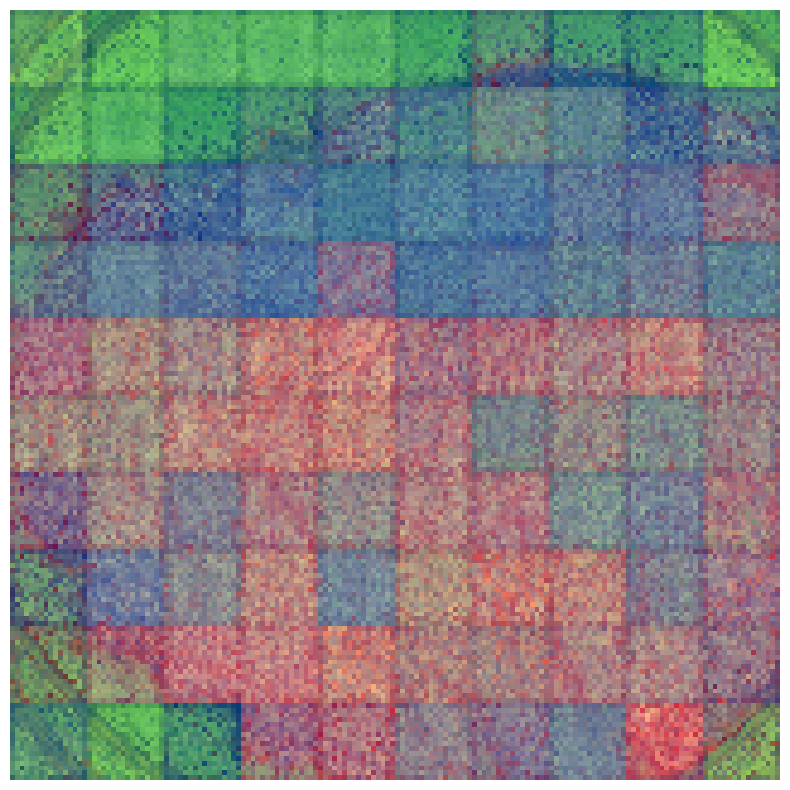

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from umap import UMAP
# similarity_matrix = cosine_similarity(features.detach().cpu().numpy())
red = PCA(n_components=3)
pca_result = red.fit_transform(img_features.reshape((-1, img_features.shape[-1])))
# pca_result = torch.nn.functional.sigmoid(torch.tensor(pca_result * 2)).numpy()
print(pca_result.shape)
pca_patches = pca_result.reshape((np.sqrt(pca_result.shape[0]).astype(int),np.sqrt(pca_result.shape[0]).astype(int),3))
plt.figure(figsize=(10,10))
to_plot = (pca_patches - pca_patches.min()) / (pca_patches.max() - pca_patches.min())
plt.imshow(to_plot)
plt.axis('off')
plt.show()

(256, 3)


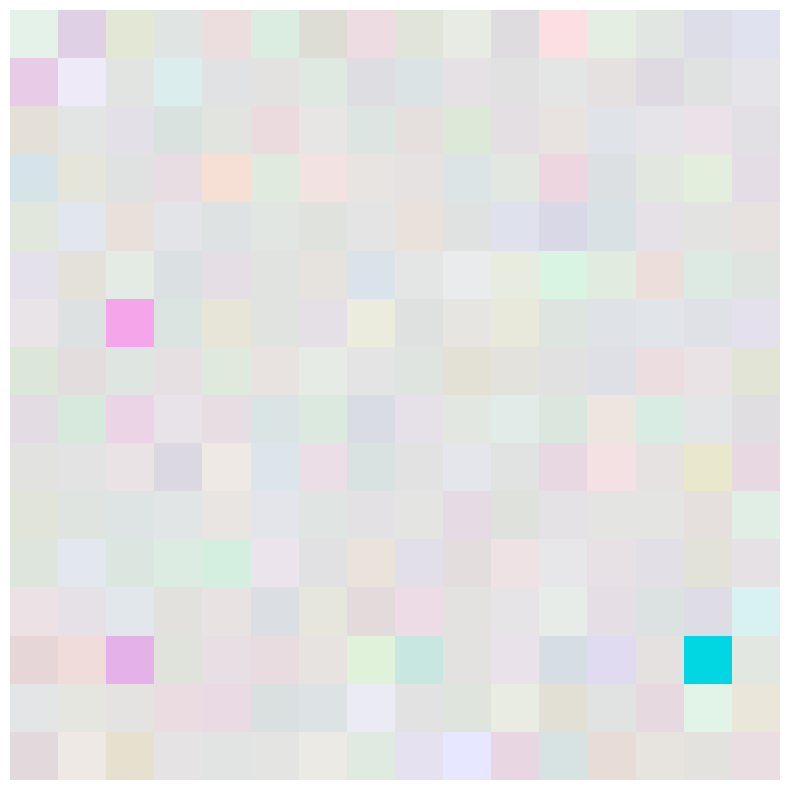

In [52]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from umap import UMAP
# similarity_matrix = cosine_similarity(features.detach().cpu().numpy())
red = PCA(n_components=3)
pca_result = red.fit_transform(features)
# pca_result = torch.nn.functional.sigmoid(torch.tensor(pca_result * 2)).numpy()
print(pca_result.shape)
pca_patches = pca_result.reshape((np.sqrt(pca_result.shape[0]).astype(int),np.sqrt(pca_result.shape[0]).astype(int),3))
plt.figure(figsize=(10,10))
plt.imshow((pca_patches - pca_patches.min()) / (pca_patches.max() - pca_patches.min()))
plt.axis('off')
plt.show()

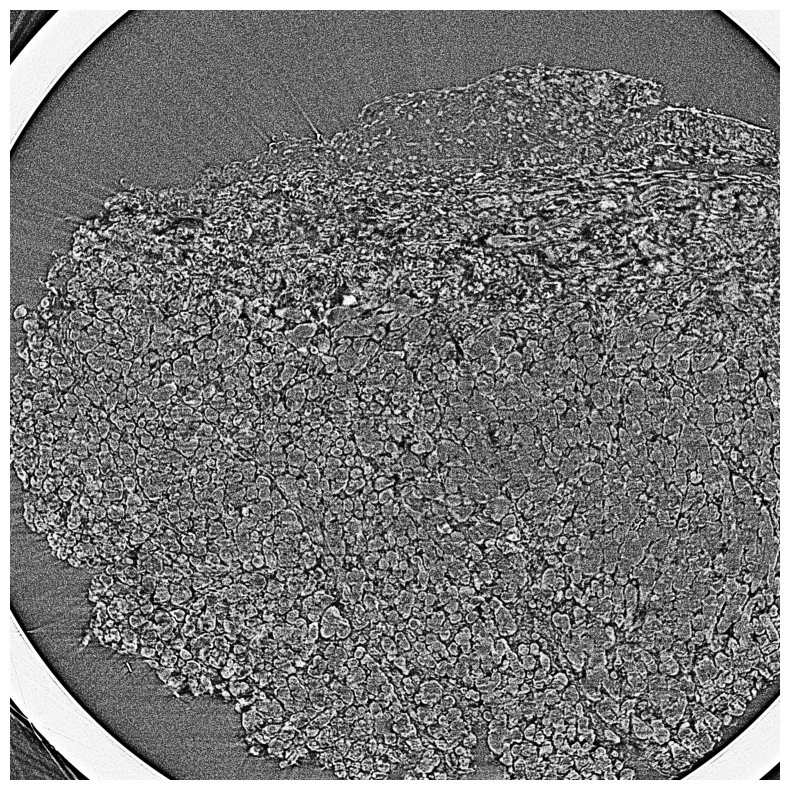

In [19]:
plt.figure(figsize=(10,10))
plt.imshow(img.detach().permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

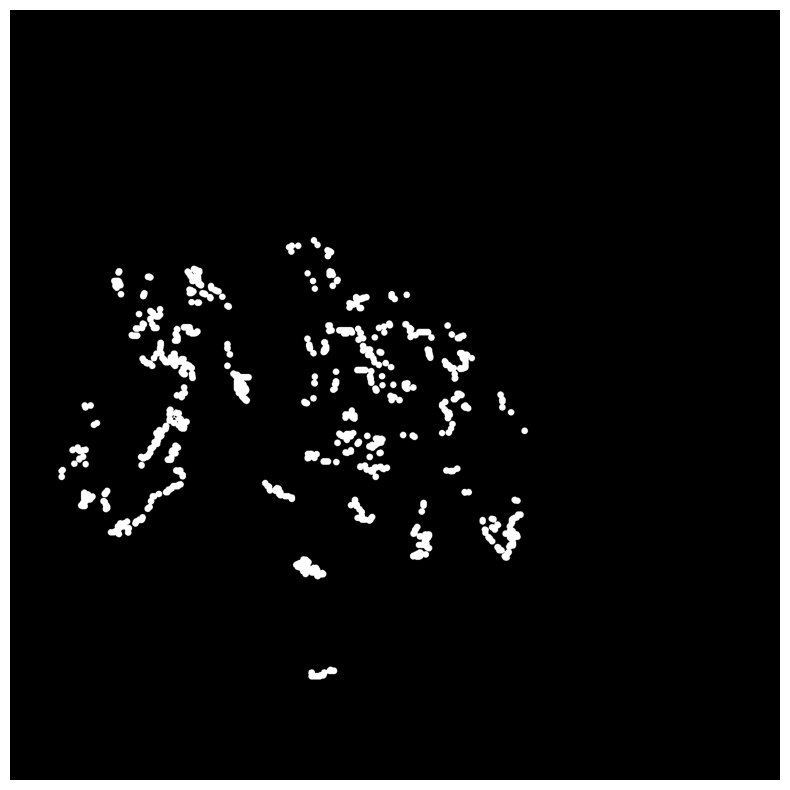

In [60]:
mask = np.load('../data/masks/' + df2.loc[0, 'mask_infiltrates'] + '.npy')
plt.figure(figsize=(10,10))
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

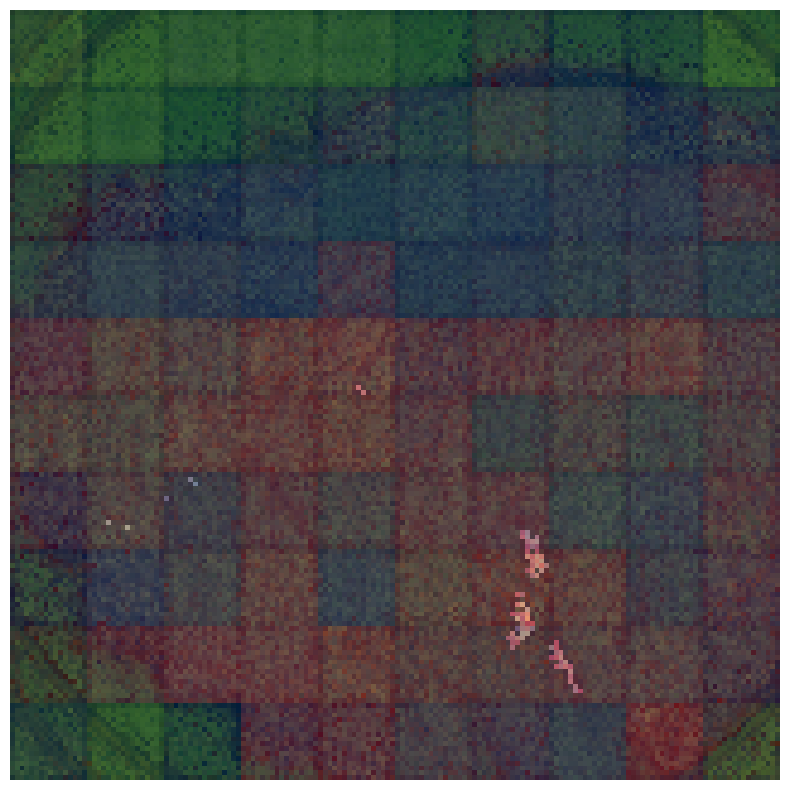

In [18]:
import cv2
mask = np.load('../data/masks/' + df2.loc[0, 'mask_infiltrates'] + '.npy')
mask = cv2.resize(mask, (to_plot.shape[1], to_plot.shape[0]))
masked_plot = 1 * to_plot * (mask[..., np.newaxis] > 0) + 0.5 * to_plot * (mask[..., np.newaxis] == 0)
plt.figure(figsize=(10,10))
plt.imshow(masked_plot)
plt.axis('off')
plt.show()

In [ ]:
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from common.preprocessing import Equalize
IMG_SIZE = (256, 256)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seg_model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
).cuda()
seg_model.load_state_dict(torch.load('../data/efficientnetb0/best_model1.pth'))

seg_transform = A.Compose([
    A.Resize(*IMG_SIZE),
    A.Equalize(p=1),
    A.Normalize(mean=(0.0,), std=(1.0,)),
    ToTensorV2()
])

t = Equalize('../common/data/07_4001_3R1212_crop.rec.8bit.tif')

seg_img = dataset[0][0]
seg_img = t(seg_img).numpy().squeeze()
seg_img = seg_transform(image=seg_img)['image'].unsqueeze(0)

with torch.no_grad():
    outputs = seg_model(seg_img.cuda())
pred_masks = A.Resize(2560,2560)(image=torch.sigmoid(outputs).squeeze().detach().cpu().numpy())['image'] > 0.5

plt.figure(figsize=(10,10))
plt.imshow(pred_masks, cmap='gray')
plt.axis('off')
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'